# Plot: per-feature term contribution heatmap

Loads the feature x term importance matrix from `1.variate_importance.ipynb` (`results/variate_importance/{organoid,single_cell}_feature_by_term_importance.parquet`) and plots the 25 best-explained features.

In [1]:
import pathlib
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from notebook_init_utils import init_notebook

warnings.filterwarnings("ignore")
root_dir, in_notebook = init_notebook()

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 50)

figures_path = pathlib.Path(root_dir, "4.linear_modeling/figures/variate_importance")
figures_path.mkdir(parents=True, exist_ok=True)
results_path = pathlib.Path(root_dir, "4.linear_modeling/results/variate_importance")

TERM_ORDER = [
    "treatment",
    "patient",
    "treatment:patient",
    "cell_count",
    "organoid_count",
    "cell_per_organoid_count",
]
feature_matrices = {
    name: pd.read_parquet(
        results_path / f"{name}_feature_by_term_importance.parquet"
    ).set_index("feature")
    for name in ["organoid", "single_cell"]
}

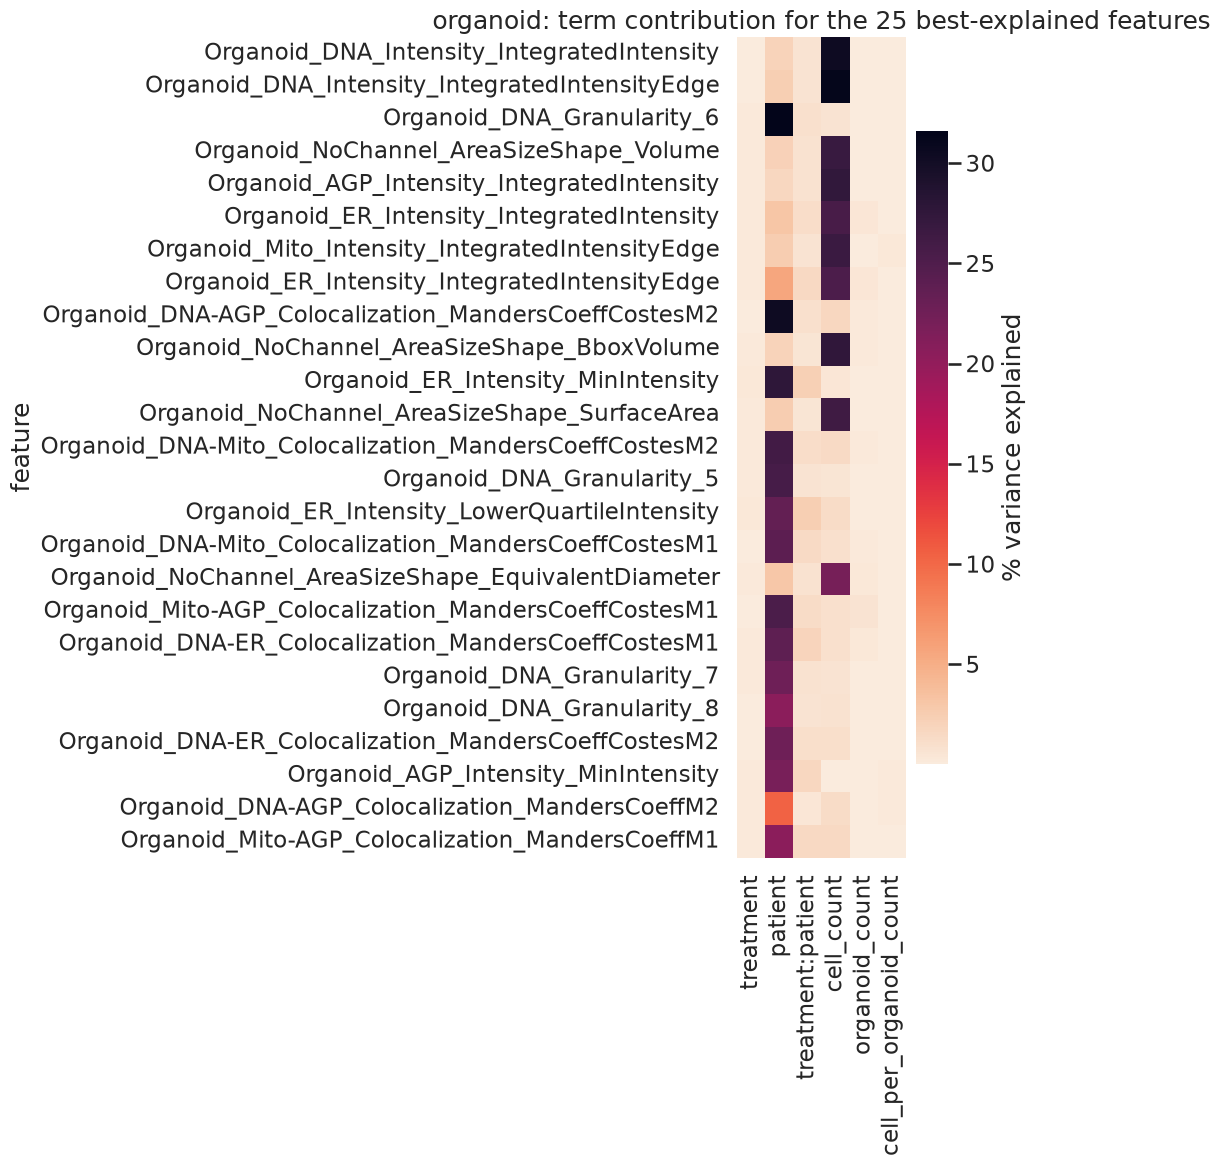

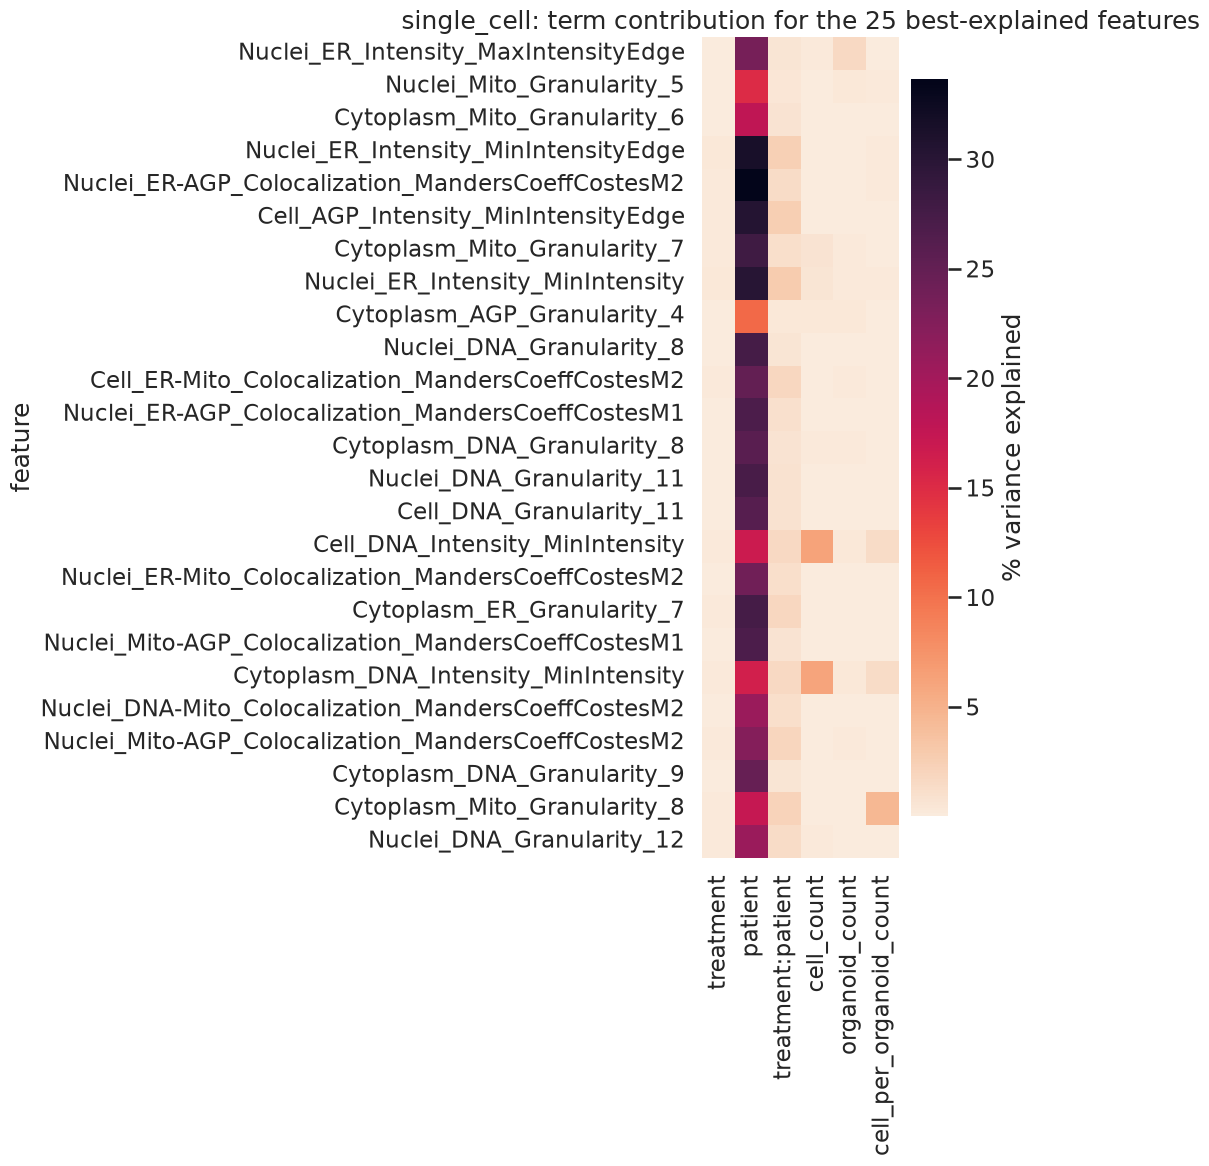

In [2]:
for name, matrix in feature_matrices.items():
    top = matrix.sort_values("mean_rsquared", ascending=False).head(25)[TERM_ORDER]
    fig, ax = plt.subplots(figsize=(10, 12))
    sns.heatmap(
        top,
        cmap="rocket_r",
        annot=False,
        cbar_kws={"label": "% variance explained"},
        ax=ax,
    )
    ax.set_title(f"{name}: term contribution for the 25 best-explained features")
    ax.set_xlabel("")
    plt.tight_layout()
    plt.savefig(
        figures_path / f"{name}_feature_by_term_heatmap.png",
        dpi=600,
        bbox_inches="tight",
    )
    plt.show()